## import necessary libraries

In [1]:
import pathlib
import re
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn import model_selection
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder
import csv
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Embedding
from tensorflow.keras.callbacks import CSVLogger
from tensorflow.keras.layers import GRU
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
import pickle
from sklearn.model_selection import KFold
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn import preprocessing
import gensim as gensim
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from tensorflow.keras.models import Sequential
from sklearn.model_selection import GridSearchCV

##EDA

In [2]:
dataset_url = 'https://raw.githubusercontent.com/supreme-lab/gender-identification/main/dataset.csv'

df = pd.read_csv(dataset_url)
df = df.dropna(subset=['text', 'gender'])
df.head()

,text,gender
0,ল্যাবে গ্রুপমেটের গ্রাফ নিজে একে দিয়েছি অনেক ...,M
1,"এরকম এক রমজান মাসের স্নিগ্ধ বিকেলে, জনৈক বুয়েট...",M
2,শিবিরবিহীন বুয়েট থেকে শিবিরের কেন্দ্রীয় কমিটির...,M
3,জনৈক বন্ধু তার বান্ধবীর সাথে দেখা করার আগে নিজ...,M
4,খুব ক্লোজ জুনিয়রের সাথে শেরে বাংলা হলের সামনের...,M


## Dataset size

In [3]:
df.index.size

15367

In [4]:
def get_male_female_keywords(posts, genders):
  # compute keyword for male and female samples
  male_keywords = []
  female_keywords = []
  for idx, post in enumerate(posts):
    splitted = post.split()
    if genders[idx] == "M":
      male_keywords.extend(splitted)
    else:
      female_keywords.extend(splitted)
  return male_keywords, female_keywords

In [5]:
def get_frequency_from_list(keywords):
  freq = {}
  for word in keywords:
    if word in freq:
      freq[word] = freq[word] + 1
    else:
      freq[word] = 1
  return freq

In [6]:
import numpy as np
import pathlib
import re
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn import model_selection
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.preprocessing import LabelEncoder
import pandas as pd
from sklearn.linear_model import SGDClassifier
import random
from sklearn.feature_selection import SelectKBest, chi2

class DataPreProcessor(object):
  def __init__(self, dataset_url):
    self.dataset_url = dataset_url

  def preprocess(self):
    # stop word list
    stop_word_file = 'https://raw.githubusercontent.com/supreme-lab/gender-identification/main/stopwords-bn.txt'
    sw_df = pd.read_csv(stop_word_file, delimiter="\t", header=None)
    stopword_list = sw_df.values.tolist()

    # load the training data
    df = pd.read_csv(self.dataset_url)

    # preprocess step 1: remove null rows
    df = df.dropna(subset=['text', 'gender'])

    # preprocess step 2: remove non Bangla characters
    author_posts = []
    author_genders = []
    for index, row in df.iterrows():
        tokens = [re.sub(r'[^\u0980-\u09FF ]+', ' ', str(row['text']))]
        author_posts.append(" ".join(tokens))
        author_genders.append(row['gender'])

    stopword_list_new = []
    for word in stopword_list:
      stopword_list_new.append(word[0])
    stopword_list = stopword_list_new
    # preprocess step 3: remove stop words
    author_posts_without_stopword = []
    i = 0
    for post in author_posts:
        i = i + 1
        # if i< 100:
        #   print("before stopword removal sent.len: ", len(post.split()))
        tokens_without_stopword = [word for word in post.split() if not word in stopword_list]
        # if i<100:
        #   print("after stopword removal sent.len: ", len(tokens_without_stopword))
        author_posts_without_stopword.append(" ".join(tokens_without_stopword))



    malekeywords, femalekeywords = get_male_female_keywords(author_posts_without_stopword, author_genders)
    # compute keyword occurrence in male and female data
    # print("compute keyword occurrence in male and female data")
    male_freq = get_frequency_from_list(malekeywords)
    female_freq = get_frequency_from_list(femalekeywords)

    # filter out keywords with occurrence <10
    # print("filter out keywords with occurrence <10 ")
    features = []
    for key, value in male_freq.items():
      if value >= 10:
        features.append(key)

    for key, value in female_freq.items():
      if value >= 10:
        features.append(key)

    # get the unique keywords
    # print("get the unique keywords")
    featureset = set(features)
    # print("featureset.len: ", len(featureset))

    # keep words which are in the featureset
    # print("keep words which are in the featureset")
    i = 0
    author_posts_without_keywords_with_occurrence1 = []
    for post in author_posts_without_stopword:
        # if i < 100:
        #   print("post.len: ", len(post.split()))
        tokens_without_keywords_with_occurrence1 = [word for word in post.split() if word in featureset]
        # if i<100:
        #   print("tokens_without_keywords_with_occurrence1.len: ", len(tokens_without_keywords_with_occurrence1))
        author_posts_without_keywords_with_occurrence1.append(" ".join(tokens_without_keywords_with_occurrence1))
        i = i + 1
    author_posts_without_stopword = author_posts_without_keywords_with_occurrence1


    return author_posts_without_stopword, author_genders

In [7]:
dataset_url = "https://raw.githubusercontent.com/supreme-lab/gender-identification/main/dataset.csv"
preprocessor = DataPreProcessor(dataset_url)
posts, genders = preprocessor.preprocess()

In [8]:
len(posts), len(genders)

(15367, 15367)

## Male, Female post raio (60:40)

In [9]:
mgs = len([g for g in genders if g == "M"])
fgs = len([g for g in genders if g == "F"])
("male: ", (100*mgs/(mgs+fgs))), ("female: ", (100*fgs/(mgs+fgs)))

(('male: ', 59.10067026745624), ('female: ', 40.89932973254376))

## sentence count for different word count ranges

In [10]:
countless5 = countgreater5less10 = countgreater10lessequal20 = countgreater20lessequal30 = countgreater30lessequal40 = countgreater40lessequal50 = countgreater50lessequal60 = countgreater60lessequal70 = countgreater70lessequal80 = countgreater80lessequal90 = countgreater90lessequal100 = countgreater100lessequal150 = countgreater150lessequal200 = countgreater200lessequal250 = countgreater250lessequal300 = countgreater300lessequal350 = countgreater350less400 = countgreater400less450 = countgreater450less500 = countgreater500 = 0

for idx, post in enumerate(posts):
  strs = post.split()
  countless5 = countless5 + 1 if len(strs) <= 5 else countless5
  countgreater5less10 = countgreater5less10 + 1 if len(strs)>5 and len(strs) <=10 else countgreater5less10
  countgreater10lessequal20 = countgreater10lessequal20 + 1 if len(strs)>10 and len(strs)<=20 else countgreater10lessequal20
  countgreater20lessequal30 = countgreater20lessequal30 + 1 if len(strs)>20 and len(strs)<=30 else countgreater20lessequal30
  countgreater30lessequal40 = countgreater30lessequal40 + 1 if len(strs)>30 and len(strs)<=40 else countgreater30lessequal40
  countgreater40lessequal50 = countgreater40lessequal50 + 1 if len(strs)>40 and len(strs)<=50 else countgreater40lessequal50
  countgreater50lessequal60 = countgreater50lessequal60 + 1 if len(strs)>50 and len(strs)<=60 else countgreater50lessequal60
  countgreater60lessequal70 = countgreater60lessequal70 + 1 if len(strs)>60 and len(strs)<=70 else countgreater60lessequal70
  countgreater70lessequal80 = countgreater70lessequal80 + 1 if len(strs)>70 and len(strs)<=80 else countgreater70lessequal80
  countgreater80lessequal90 = countgreater80lessequal90 + 1 if len(strs)>80 and len(strs)<=90 else countgreater80lessequal90
  countgreater90lessequal100 = countgreater90lessequal100 + 1 if len(strs)>90 and len(strs)<=100 else countgreater90lessequal100
  countgreater100lessequal150 = countgreater100lessequal150 + 1 if len(strs)>100 and len(strs)<=150 else countgreater100lessequal150
  countgreater150lessequal200 = countgreater150lessequal200 + 1 if len(strs)>150 and len(strs)<=200 else countgreater150lessequal200
  countgreater200lessequal250 = countgreater200lessequal250 + 1 if len(strs)>200 and len(strs)<=250 else countgreater200lessequal250
  countgreater250lessequal300 = countgreater250lessequal300 + 1 if len(strs)>250 and len(strs)<=300 else countgreater250lessequal300
  countgreater300lessequal350 = countgreater300lessequal350 + 1 if len(strs)>300 and len(strs)<=350 else countgreater300lessequal350
  countgreater350less400 = countgreater350less400 + 1 if len(strs)>350 and len(strs)<=400 else countgreater350less400
  countgreater400less450 = countgreater400less450 + 1 if len(strs)>400 and len(strs)<=450 else countgreater400less450
  countgreater450less500 = countgreater450less500 + 1 if len(strs)>450 and len(strs)<=500 else countgreater450less500
  countgreater500 = countgreater500 + 1 if len(strs)>500 else countgreater500

total_count = countless5 + countgreater5less10 + countgreater10lessequal20 + countgreater20lessequal30 + countgreater30lessequal40 + countgreater40lessequal50 + countgreater50lessequal60 + countgreater60lessequal70 + countgreater70lessequal80 + countgreater80lessequal90 + countgreater90lessequal100 + countgreater100lessequal150 + countgreater150lessequal200 + countgreater200lessequal250 + countgreater250lessequal300 + countgreater300lessequal350 + countgreater350less400 + countgreater400less450 + countgreater450less500 + countgreater500
print("total_count: ", total_count)

total_count:  15367


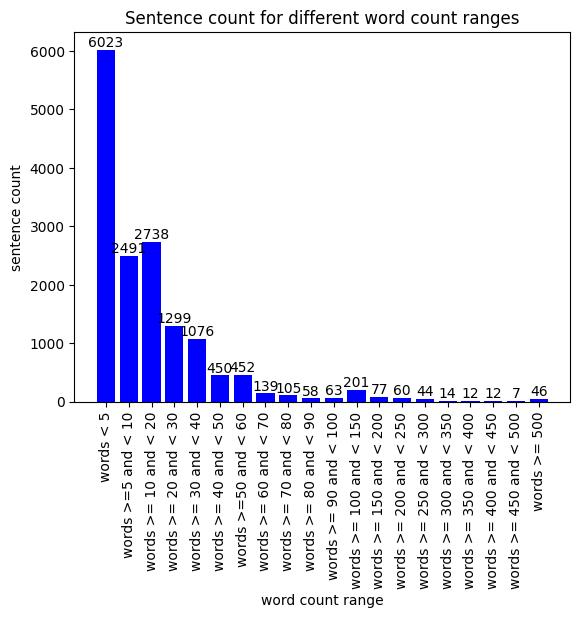

In [11]:
import matplotlib.pyplot as plt

y_axis_values = [
    countless5,
    countgreater5less10, countgreater10lessequal20, countgreater20lessequal30, countgreater30lessequal40, countgreater40lessequal50,
    countgreater50lessequal60, countgreater60lessequal70, countgreater70lessequal80, countgreater80lessequal90, countgreater90lessequal100,
    countgreater100lessequal150, countgreater150lessequal200, countgreater200lessequal250, countgreater250lessequal300, countgreater300lessequal350,
    countgreater350less400, countgreater400less450, countgreater450less500, countgreater500
    ]
x_axis_values = [
    "words < 5", "words >=5 and < 10", "words >= 10 and < 20", "words >= 20 and < 30", "words >= 30 and < 40", "words >= 40 and < 50",
    "words >=50 and < 60", "words >= 60 and < 70", "words >= 70 and < 80", "words >= 80 and < 90", "words >= 90 and < 100", "words >= 100 and < 150",
    "words >= 150 and < 200", "words >= 200 and < 250", "words >= 250 and < 300", "words >= 300 and < 350", "words >= 350 and < 400", "words >= 400 and < 450",
    "words >= 450 and < 500", "words >= 500"
]

# Create a bar chart
plt.bar(x_axis_values, y_axis_values, color='blue')

# Adding labels and title
plt.xlabel('word count range')
plt.ylabel('sentence count')
plt.title('Sentence count for different word count ranges')

# Adding values on top of the bars
for i, v in enumerate(y_axis_values):
    plt.text(i, v + 0.5, str(v), ha='center', va='bottom')

# Rotate x-axis tick labels vertically
plt.xticks(rotation='vertical')

# Show the bar chart
plt.show()

## keep posts which length between 5 and 300

In [12]:
posts_new = []
genders_new = []
for idx, post in enumerate(posts):
  strs = post.split()
  if len(strs) >=5 and len(strs)<=80:
    posts_new.append(post)
    genders_new.append(genders[idx])

("posts_new.len: ", len(posts_new)), ("genders_new.len: ", len(genders_new))

(('posts_new.len: ', 9340), ('genders_new.len: ', 9340))

In [13]:
mgs = len([g for g in genders_new if g == "M"])
fgs = len([g for g in genders_new if g == "F"])
("male: ", (100*mgs/(mgs+fgs))), ("female: ", (100*fgs/(mgs+fgs)))

(('male: ', 60.942184154175585), ('female: ', 39.057815845824415))

## ModelTraditional with TFIDF feature

In [24]:
from sklearn.model_selection import GridSearchCV
class ModelTraditionalWithTFIDF():
  def __init__(self, posts, genders, model_name) -> None:
    self.author_posts = posts
    self.author_genders = genders
    self.model_name = model_name
    self.model = None

  def train(self):
    label_encoder = LabelEncoder()
    label_encoder.fit(self.author_genders)
    labels = label_encoder.transform(self.author_genders)

    train_x, test_x, train_y, test_y = model_selection.train_test_split(self.author_posts, labels, test_size=0.2)

    male_list = []
    female_list = []

    self.tfidf_vectorizer = TfidfVectorizer(max_features=1000, analyzer='word', ngram_range=(1, 3))
    self.tfidf_vectorizer.fit(self.author_posts)

    vocabs = self.tfidf_vectorizer.get_feature_names_out()

    train_x_tfidf = self.tfidf_vectorizer.transform(train_x)
    test_x_tfidf = self.tfidf_vectorizer.transform(test_x)

    model = None
    if self.model_name == "SGD":
      sgdc = SGDClassifier()

      sgdc_params = {
          'loss':['hinge', 'log_loss'],
          'penalty':['elasticnet'],
          'max_iter':[1000],
          'alpha':np.logspace(-4, 4, 10),
          'l1_ratio':[0.05,0.06,0.07],
          'tol': [0.01]
      }

      sgdc_gs = GridSearchCV(sgdc, sgdc_params, cv=5, verbose=1, n_jobs=1)

      #Here I fit the model to my dataset
      sgdc_gs.fit(train_x_tfidf, train_y)
      author_gender_pred = sgdc_gs.predict(test_x_tfidf)

      accuracy = accuracy_score(test_y, author_gender_pred)
      precision = precision_score(test_y, author_gender_pred)
      recall = recall_score(test_y, author_gender_pred)
      f1 = f1_score(test_y, author_gender_pred)
      # model = SGDClassifier(max_iter=1000, tol=0.01)
    elif self.model_name == 'RF':
      param_grid = {
          'n_estimators': [100, 200],
          'max_features': ['sqrt', 'log2'],
          'max_depth' : [2,4,5,6,7,8],
          'criterion' :['gini', 'entropy']
      }
      rfc=RandomForestClassifier(random_state=42)
      cv_rfc = GridSearchCV(estimator=rfc, param_grid=param_grid, cv= 5)
      cv_rfc.fit(train_x_tfidf, train_y)
      author_gender_pred = cv_rfc.predict(test_x_tfidf)

      accuracy = accuracy_score(test_y, author_gender_pred)
      precision = precision_score(test_y, author_gender_pred)
      recall = recall_score(test_y, author_gender_pred)
      f1 = f1_score(test_y, author_gender_pred)
      # model = RandomForestClassifier(max_depth=2, random_state=0)
    elif self.model_name == 'NB':
      # Create a pipeline with CountVectorizer and MultinomialNB
      model = MultinomialNB()

      # Define the parameter grid
      param_grid = {
          'alpha': [0.1, 0.5, 1.0],
      }

      # Create GridSearchCV
      cv_nb = GridSearchCV(model, param_grid, cv=5, scoring='accuracy')

      # Fit the grid search to the data
      cv_nb.fit(train_x_tfidf, train_y)
      author_gender_pred = cv_nb.predict(test_x_tfidf)

      accuracy = accuracy_score(test_y, author_gender_pred)
      precision = precision_score(test_y, author_gender_pred)
      recall = recall_score(test_y, author_gender_pred)
      f1 = f1_score(test_y, author_gender_pred)
      # model = MultinomialNB()
    elif self.model_name == 'SVM':
      model = SVC(kernel='linear')
      model.fit(train_x_tfidf, train_y)
      author_gender_pred = model.predict(test_x_tfidf)

      accuracy = accuracy_score(test_y, author_gender_pred)
      precision = precision_score(test_y, author_gender_pred)
      recall = recall_score(test_y, author_gender_pred)
      f1 = f1_score(test_y, author_gender_pred)

    elif self.model_name == 'LR':
      model = LogisticRegression(random_state=0)
      model.fit(train_x_tfidf, train_y)
      author_gender_pred = model.predict(test_x_tfidf)

      accuracy = accuracy_score(test_y, author_gender_pred)
      precision = precision_score(test_y, author_gender_pred)
      recall = recall_score(test_y, author_gender_pred)
      f1 = f1_score(test_y, author_gender_pred)

    elif self.model_name == 'DT':
      model = DecisionTreeClassifier(random_state=0)
      model.fit(train_x_tfidf, train_y)
      author_gender_pred = model.predict(test_x_tfidf)

      accuracy = accuracy_score(test_y, author_gender_pred)
      precision = precision_score(test_y, author_gender_pred)
      recall = recall_score(test_y, author_gender_pred)
      f1 = f1_score(test_y, author_gender_pred)

    elif self.model_name == 'KNN':
      model =  KNeighborsClassifier(n_neighbors=3)
      model.fit(train_x_tfidf, train_y)
      author_gender_pred = model.predict(test_x_tfidf)

      accuracy = accuracy_score(test_y, author_gender_pred)
      precision = precision_score(test_y, author_gender_pred)
      recall = recall_score(test_y, author_gender_pred)
      f1 = f1_score(test_y, author_gender_pred)



    return accuracy, precision, recall, f1


In [15]:
model = ModelTraditionalWithTFIDF(posts, genders, "SGD")
accuracy, precision, recall, f1 = model.train()
print(accuracy, precision, recall, f1)

Fitting 5 folds for each of 60 candidates, totalling 300 fits
0.6857514638906962 0.6797608881298036 0.8805309734513275 0.7672289156626505


In [16]:
model = ModelTraditionalWithTFIDF(posts, genders, "RF")
accuracy, precision, recall, f1 = model.train()
print(accuracy, precision, recall, f1)

0.6314248536109304 0.6210702341137124 1.0 0.7662471631937281


In [22]:
model = ModelTraditionalWithTFIDF(posts, genders, "NB")
accuracy, precision, recall, f1 = model.train()
print(accuracy, precision, recall, f1)

0.6815224463240078 0.6714165968147527 0.8914858096828047 0.7659574468085106


In [25]:
model = ModelTraditionalWithTFIDF(posts, genders, "LR")
accuracy, precision, recall, f1 = model.train()
print(accuracy, precision, recall, f1)

0.6860767729342876 0.6874729085392285 0.8666666666666667 0.7667391829828378


In [26]:
model = ModelTraditionalWithTFIDF(posts, genders, "NB")
accuracy, precision, recall, f1 = model.train()
print(accuracy, precision, recall, f1)

0.6789199739752765 0.6629927935565918 0.8906605922551253 0.7601458080194411


In [27]:
model = ModelTraditionalWithTFIDF(posts, genders, "DT")
accuracy, precision, recall, f1 = model.train()
print(accuracy, precision, recall, f1)

0.6610279765777488 0.6886792452830188 0.7926167209554832 0.7370015143866735


In [28]:
model = ModelTraditionalWithTFIDF(posts, genders, "KNN")
accuracy, precision, recall, f1 = model.train()
print(accuracy, precision, recall, f1)

0.6613532856213403 0.6528253424657534 0.8689458689458689 0.7455389880224884


In [29]:
model = ModelTraditionalWithTFIDF(posts, genders, "SVM")
accuracy, precision, recall, f1 = model.train()
print(accuracy, precision, recall, f1)

0.6727391021470397 0.6689132266217355 0.8783185840707964 0.7594452415112387


## ModelDL with TFIDF features

In [ ]:
class ModelDLWithTFIDF():
  def __init__(self, posts, genders, model, batch, epochs) -> None:
    self.batch = batch
    self.epochs = epochs
    self.author_posts = posts

    self.author_genders = genders
    self.model=Sequential()
    if model == 'LSTM':
      self.model.add(LSTM(300, return_sequences=False))
    elif model == 'GRU':
      self.model.add(GRU(300, return_sequences=False))

  def train(self):
    labels = np.asarray(pd.get_dummies(self.author_genders))
    train_x, test_x, train_y, test_y = model_selection.train_test_split(self.author_posts, labels, test_size=0.3)

    male_list = []
    female_list = []

    self.tfidf_vectorizer = TfidfVectorizer(max_features=600, analyzer='word', ngram_range=(1, 3))
    self.tfidf_vectorizer.fit(self.author_posts)

    train_x_tfidf = self.tfidf_vectorizer.transform(train_x)
    test_x_tfidf = self.tfidf_vectorizer.transform(test_x)
    train_x_tfidf_dense = train_x_tfidf.toarray()
    test_x_tfidf_dense = test_x_tfidf.toarray()

    train_x_tfidf_dense = train_x_tfidf_dense.reshape(train_x_tfidf_dense.shape[0],1,train_x_tfidf_dense.shape[-1])
    test_x_tfidf_dense = test_x_tfidf_dense.reshape(test_x_tfidf_dense.shape[0],1,test_x_tfidf_dense.shape[-1])

    # compile model
    self.model.add(Dense(train_y.shape[1], activation='sigmoid'))
    self.model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

    history_model = self.model.fit(train_x_tfidf_dense, train_y, self.batch, self.epochs, validation_split=0.25)
    scores = self.model.evaluate(test_x_tfidf_dense, test_y, verbose=0)
    author_gender_test_predictions = np.argmax(self.model.predict(test_x_tfidf_dense), axis=1)

    author_gender_original_label = np.argmax(test_y, axis=1)
    accuracy = accuracy_score(author_gender_original_label, author_gender_test_predictions)
    precision = precision_score(author_gender_original_label, author_gender_test_predictions)
    recall = recall_score(author_gender_original_label, author_gender_test_predictions)
    f1 = f1_score(author_gender_original_label, author_gender_test_predictions)
    return accuracy, precision, recall, f1

## ModelDLWithWordEmbedding with embedding features




In [ ]:
class ModelDLWithWordEmbedding(object):
    def __init__(self, cbow=1, cbow_trainable=1, sg=0, sg_trainable=0, data_split=2, batch=32, epochs=5, model_name="GRU"):
        self.model = Sequential()
        self.cbow = cbow
        self.cbow_trainable = cbow_trainable
        self.sg = sg
        self.sg_trainable = sg_trainable
        self.data_split = data_split
        self.batch = batch
        self.epochs = epochs
        self.model_name = model_name


    def get_stop_words(self):
      stop_word_file = 'https://raw.githubusercontent.com/supreme-lab/gender-identification/main/stopwords-bn.txt'
      sw_df = pd.read_csv(stop_word_file, delimiter="\t", header=None)
      return sw_df.values.tolist()

    def convert_text_to_word_vector(self,author_post,author_gender):
      maxlen = 100
      max_words = 1000

      tokenizer = Tokenizer(num_words=max_words)
      tokenizer.fit_on_texts(author_post)
      sequences = tokenizer.texts_to_sequences(author_post)

      word_index = tokenizer.word_index
      data = pad_sequences(sequences, maxlen=maxlen)
      labels = np.asarray(pd.get_dummies(author_gender)) #
      return data, labels

    def make_dataset(self, X_data, y_data, n_splits):
      X_train_dataset= []
      X_test_dataset = []
      y_train_dataset=  []
      y_test_dataset = []

      for train_index, test_index in KFold(n_splits).split(X_data):
              X_train, X_test = X_data[train_index], X_data[test_index]
              y_train, y_test = y_data[train_index], y_data[test_index]
              X_train_dataset.append(X_train)
              X_test_dataset.append(X_test)
              y_train_dataset.append(y_train)
              y_test_dataset.append(y_test)

      return X_train_dataset, X_test_dataset, y_train_dataset, y_test_dataset

    def get_embedding_vector(self, author_post):
      tokenized_lines = []
      for single_line in author_post:
        tokenized_lines.append(single_line.split())

      if self.cbow == 1:
        # Word2Vec(sentences=common_texts, vector_size=100, window=5, min_count=1, workers=4)
        self.word_model = gensim.models.Word2Vec(tokenized_lines, sg=0, vector_size=300, window=5, min_count=1, workers=4)
      elif self.sg == 1:
        self.word_model = gensim.models.Word2Vec(tokenized_lines, sg=1, vector_size=300, window=5, min_count=1, workers=4)

      embedding_matrix = np.zeros((len(self.word_model.wv.vectors) + 1, 300))  # 29534*300 --> Total word = 29534 ---> prottek word er vector e 300ta element
      for i, vec in enumerate(self.word_model.wv.vectors):
        embedding_matrix[i] = vec
      return embedding_matrix

    def get_model(self, embedding_matrix, author_post_train, author_gender_train):
        model = Sequential()  # 1 * 100 ---
        if self.cbow_trainable == 1:  # 100 * 300  #input_length = 100
            model.add(
                Embedding(len(self.word_model.wv.vectors) + 1, 300, input_length=author_post_train.shape[1], weights=[embedding_matrix],
                          trainable=True))  # size of embedding matrix is 100*300
        elif self.sg_trainable == 1:
            model.add(
                Embedding(len(self.word_model.wv.vectors) + 1, 300, input_length=author_post_train.shape[1], weights=[embedding_matrix],
                          trainable=True))
        else:
            model.add(
                Embedding(len(self.word_model.wv.vectors) + 1, 300, input_length=author_post_train.shape[1], weights=[embedding_matrix],
                          trainable=False))

        # compile model
        if self.model_name == "GRU":
          model.add(GRU(300, return_sequences=False))
        elif self.model_name == "LSTM":
          model.add(LSTM(300, return_sequences=False))

        model.add(Dense(author_gender_train.shape[1], activation="softmax"))
        model.summary()
        model.compile(optimizer="rmsprop", loss="binary_crossentropy", metrics=['acc'])
        return model

    def train(self, posts, genders):
        author_post, author_gender = posts, genders

        data , labels = self.convert_text_to_word_vector(author_post, author_gender) #size is post_number*100
        X_train_dataset, X_test_dataset, y_train_dataset, y_test_dataset = self.make_dataset(data, labels, self.data_split)
        embedding_matrix = self.get_embedding_vector(author_post) # 29534 * 100 dimension er ekta matrix

        acc_per_fold = []
        loss_per_fold = []
        precision_per_fold = []
        recall_per_fold = []
        f1_score_per_fold = []

        for i in range(len(X_train_dataset)):
            author_post_train = X_train_dataset[i] # 400*100
            author_gender_train = y_train_dataset[i]
            author_post_test = X_test_dataset[i]
            author_gender_test = y_test_dataset[i]
            #batch, epochs = 50, 100
            batch, epochs = self.batch, self.epochs
            model = self.get_model(embedding_matrix, author_post_train, author_gender_train)
            #csv_logger,tensorboard_callback = self.get_csvlogger_tensorflow_callback()
            history_model = model.fit(author_post_train, author_gender_train, batch, epochs,
                                       validation_split=0.2)
            #, callbacks=[csv_logger, tensorboard_callback])
            scores = model.evaluate(author_post_test, author_gender_test, verbose=0)
            # acc_per_fold.append(scores[1] * 100)
            loss_per_fold.append(scores[0])

            author_gender_test_predictions = model.predict(author_post_test)
            author_gender_predicted_label = np.argmax(author_gender_test_predictions, axis=1)
            author_gender_original_label = np.argmax(author_gender_test, axis=1)

            TP = tf.math.count_nonzero(author_gender_predicted_label * author_gender_original_label, dtype=tf.float32)
            TN = tf.math.count_nonzero((author_gender_predicted_label - 1) * (author_gender_original_label - 1),dtype=tf.float32)
            FP = tf.math.count_nonzero(author_gender_predicted_label * (author_gender_original_label - 1), dtype=tf.float32)
            FN = tf.math.count_nonzero((author_gender_predicted_label - 1) * author_gender_original_label, dtype=tf.float32)

            # print("True positive: ", TP, "True negative: ", TN, "False positive: ", FP, "False negative: ", FN)
            print("TP, TN, FP, FN")
            print(TP, TN, FP, FN)

            accuracy = ( TP + TN ) / (TP + FP +FP +FN)
            precision = TP / (TP + FP)
            recall = TP / (TP + FN)
            f1 = 2 * precision * recall / (precision + recall)

            accuracy = accuracy_score(author_gender_original_label, author_gender_predicted_label)
            precision = precision_score(author_gender_original_label, author_gender_predicted_label)
            recall = recall_score(author_gender_original_label, author_gender_predicted_label)
            f1 = f1_score(author_gender_original_label, author_gender_predicted_label)

            acc_per_fold.append(accuracy)
            precision_per_fold.append(precision)
            recall_per_fold.append(recall)
            f1_score_per_fold.append(f1)

        sum_acc = 0
        sum_loss = 0
        sum_precision = 0
        sum_recall = 0
        sum_f1_score = 0

        for i, acc in enumerate(acc_per_fold):
            sum_acc = sum_acc + acc
            sum_loss = sum_loss+ loss_per_fold[i]
            sum_precision = sum_precision + precision_per_fold[i]
            sum_recall = sum_recall + recall_per_fold[i]
            sum_f1_score = sum_f1_score + f1_score_per_fold[i]

        avg_acc = sum_acc/10.0
        avg_precision = sum_precision /10.0
        avg_recall = sum_recall/10.0
        avg_f1 = sum_f1_score /10.0

        return acc_per_fold, precision_per_fold, recall_per_fold, f1_score_per_fold, avg_acc, avg_precision, avg_recall, avg_f1
# cbow=1, cbow_trainable=1, sg=0, sg_trainable=0, data_split=2, batch=32, epochs=5
# acc_per_fold, precision_per_fold, recall_per_fold, f1_score_per_fold, avg_acc, avg_precision, avg_recall, avg_f1 = ModelDLWithWordEmbedding(cbow=1, cbow_trainable=1, sg=0, sg_trainable=0, data_split=2, batch=32, epochs=5, model_name="GRU").train(posts_new, genders_new)
# print("acc_per_fold: ", acc_per_fold)
# print("precision_per_fold: ", precision_per_fold)
# print("recall_per_fold: ", recall_per_fold)
# print("f1_score_per_fold: ", f1_score_per_fold)
# print("avg_acc: ", avg_acc)
# print("avg_precision: ", avg_precision)
# print("avg_recall: ", avg_recall)
# print("avg_f1: ", avg_f1)

## Stylometric Feature

In [ ]:
import re

class Character_Based_Feature(object):

    # Extract F1 : Total number of characters C
    def find_total_no_of_chacater(self,article):
        return len(article)

    # Extract F2 : Total number of Letters ('অ','৺')/C
    def find_total_no_letter(self,article):
        sentence = re.sub(r'[^\u0995-\u09b9\u09ce\u09dc-\u09df\u0985-\u0994\u09be-\u09cc\u09d7\u0981-\u0983\u09cd]+', '', article)
        return len(sentence)

    # Extract F3: Total number of Digits
    def find_total_digits(self,article):
        article = re.sub(r'[^\u09E6-\u09EF]', '', article)
        return len(article)

    # Extract F4 : Total number of White-space characters /C
    def find_total_no_of_white_space(self,article):
        return article.count(' ')

    # Extract F5: Total number of tab space characters / C
    def find_total_no_of_tab(self,article):
        articleTemp = re.sub(' {2,}', 'A', article)
        article = re.sub(' {2,}', '', article)
        return len(articleTemp)-len(article)

    # Extract F6 : Total number of elongation characters/C
    def find_total_elongations(self,str):
        regex = re.compile(r"(.)\1{2}")
        list = [word for word in str.split() if regex.search(word)]
        return len(list)

    # Extract F7-17 : Total number of dependent vowel characters/C
    def find_total_dependent_vowels(self,sentence):
        matra = [u'\u09BE', u'\u09BF', u'\u09C0', u'\u09C1', u'\u09C2', u'\u09C3', u'\u09C4', u'\u09C7', u'\u09C8', u'\u09CB',u'\u09CC']

        count_list = []
        for count, ch in enumerate(matra):
            count_list.append(sentence.count(ch))

        return count_list

    # Extract F18-41 : Total number of special characters/C
    def find_total_special_characters(self,sentence):
        list = ['«', '»', '#', '$', '%', '&', '*', '(', ')', '<', '>', '{', '}', '[', ']', '_', '+', '-', '=', '^', '/', '\\', '|','~']

        count_list = []
        for count, ch in enumerate(list):
            count_list.append(sentence.count(ch))

        return count_list


    # Extract F42-91 : Total number of individual characters/C
    def find_total_individual_letters(self,sentence):
        list = ['অ', 'আ', 'ই', 'ঈ', 'উ', 'ঊ', 'ঋ', 'এ', 'ঐ','ও', 'ঔ',
                'ক', 'খ', 'গ', 'ঘ', 'ঙ', 'চ', 'ছ', 'জ', 'ঝ', 'ঞ', 'ট', 'ঠ',
                'ড', 'ঢ', 'ণ', 'ত', 'থ','দ', 'ধ','ন', 'প', 'ফ', 'ব', 'ভ', 'ম',
                'য', 'র', 'ল', 'শ', 'ষ','স', 'হ', 'ড়', 'ঢ়', 'য়', 'ৎ','ং', 'ঃ' ,'৺']

        count_list = []
        for count, ch in enumerate(list):
            count_list.append(sentence.count(ch))

        return count_list

    def featureCollectionFromData(self,article):
        total_character = self.find_total_no_of_chacater(article)  # Extract F1 : Total number of characters C
        total_letter = self.find_total_no_letter(article) # Extract F2 : Total number of Letters ('অ','৺')/C
        total_digits = self.find_total_digits(article) # Extract F3: Total number of Digits

        total_white_space = self.find_total_no_of_white_space(article) # Extract F4 : Total number of White-space characters /C
        total_no_of_tab = self.find_total_no_of_tab(article) # Extract F5: Total number of tab space characters / C
        total_elongations = self.find_total_elongations(article) # Extract F6 : Total number of elongation characters/C
        total_dependent_vowels = self.find_total_dependent_vowels(article) # Extract F7-17 : Total number of dependenyvowel characters/C
        total_special_characters = self.find_total_special_characters(article) # Extract F18-41 : Total number of special characters/C
        total_individual_letters = self.find_total_individual_letters(article) # Extract F42-91 : Total number of individual characters/C

        feature = []
        feature.append(total_character)
        feature.append(total_letter/total_character)
        feature.append(total_digits/total_character)
        feature.append(total_white_space/total_character)
        feature.append(total_no_of_tab/total_character)
        feature.append(total_elongations)

        for count in total_dependent_vowels:
            feature.append(count)

        for count in total_special_characters:
            feature.append(count/total_character)

        for count in total_individual_letters:
            feature.append(count/total_character)

        return feature


# if __name__ == "__main__":
#     str = "বাংলাাাাাাাাাাাাাাাাাাাাাাাাাাাাাাাা ভাাাাাাাাাাাাষাাাাাাাাাাাাাাাাাাাাাাাাাাাাাা ০১২৩৪৫৬৭৮৯ ০১২৩৪৫৬৭৮৯ ০১২৩৪৫৬৭৮৯ ০১২৩৪৫৬৭৮৯ বাংলা ভাষা বাংলা ভাষা বাঙলা বাঙ্গলা তথা বাঙ্গালা নামগুলোতেও পরিচিত একটি ইন্দো আর্য ভাষা যা দক্ষিণ এশিয়ার বাঙালি জাতির প্রধান কথ্য ও লেখ্য ভাষা"
#     feature = Character_Based_Feature().featureCollectionFromData(str)
#     print(feature)

In [ ]:
import xlrd
import pandas

class ContentBasedFeatures(object):

    def __init__(self):
        self.filename = "/content/dataset.xlsx"
        self.economy_words = []
        self.policy_words = []
        self.social_words = []
        self.sport_words = []
        self.negative_words = []

    def read_words_from_xlsx(self):
        #wordbook = xlrd.open_workbook(self.filename)
        # economy_worksheet = wordbook.sheet_by_name("economy")
        # policy_worksheet = wordbook.sheet_by_name("policy")
        # social_worksheet = wordbook.sheet_by_name("social")
        # sport_worksheet = wordbook.sheet_by_name("sport")
        # negative_worksheet = wordbook.sheet_by_name("negative")

        df = pandas.read_excel('/content/dataset.xlsx', engine='openpyxl',sheet_name="economy")
        self.economy_words = df.iloc[:, 1].values.tolist()
        df = pandas.read_excel('/content/dataset.xlsx', engine='openpyxl',sheet_name="policy")
        self.policy_words = df.iloc[:, 1].values.tolist()
        df = pandas.read_excel('/content/dataset.xlsx', engine='openpyxl',sheet_name="social")
        self.social_words = df.iloc[:, 1].values.tolist()
        df = pandas.read_excel('/content/dataset.xlsx', engine='openpyxl',sheet_name="sport")
        self.sport_words = df.iloc[:, 1].values.tolist()
        df  = pandas.read_excel('/content/dataset.xlsx', engine='openpyxl',sheet_name="negative")
        self.negative_words = df.iloc[:, 1].values.tolist()

    def get_content_based_features(self, text):
        features = []
        single_keyword_phrases = text.split()
        double_keyword_phrases = []
        triple_keyword_phrases = []

        l = len(single_keyword_phrases)
        l = int(2*int(l/2))
        for i in range(0, l, 2):
            double_keyword_phrase = " ".join(single_keyword_phrases[i:i + 2])
            double_keyword_phrases.append(double_keyword_phrase)

        l = int(3 * int(l / 3))
        for i in range(0, l, 3):
            triple_keyword_phrase = " ".join(single_keyword_phrases[i:i + 3])
            triple_keyword_phrases.append(triple_keyword_phrase)

        economy_word_count = 0
        policy_word_count = 0
        social_word_count = 0
        sport_word_count = 0
        negative_word_count = 0

        #print("***calculate triple keyword phrase***")
        for phrase in triple_keyword_phrases:
            if phrase in self.economy_words:
                economy_word_count += 1
            if phrase in self.policy_words:
                policy_word_count += 1
            if phrase in self.social_words:
                social_word_count += 1
            if phrase in self.sport_words:
                sport_word_count += 1
            if phrase in self.negative_words:
                negative_word_count += 1

        #print("***calculate double keyword phrase***")
        for phrase in double_keyword_phrases:
            if phrase in self.economy_words:
                economy_word_count += 1
            if phrase in self.policy_words:
                policy_word_count += 1
            if phrase in self.social_words:
                social_word_count += 1
            if phrase in self.sport_words:
                sport_word_count += 1
            if phrase in self.negative_words:
                negative_word_count += 1

        for phrase in single_keyword_phrases:
            if phrase in self.economy_words:
                economy_word_count += 1
            if phrase in self.policy_words:
                policy_word_count += 1
            if phrase in self.social_words:
                social_word_count += 1
            if phrase in self.sport_words:
                sport_word_count += 1
            if phrase in self.negative_words:
                negative_word_count += 1

        features.append(economy_word_count)
        features.append(policy_word_count)
        features.append(social_word_count)
        features.append(sport_word_count)
        features.append(negative_word_count)

        return features


# if __name__ == "__main__":

#     contentFeaturesObj = ContentBasedFeatures()
#     text = "স্বাস্থ্য মন্ত্রণালয়ের অধীন জনস্বাস্থ্য ইনস্টিটিউটের রাজ্য তহবিল"
#     contentFeaturesObj.read_words_from_xlsx()
#     f = contentFeaturesObj.get_content_based_features(text)
#     print("features")
#     print(f)


In [ ]:

class StructureBasedFeatures(object):

    def __init__(self):
        self.number_of_lines = 0
        self.number_of_paragraphs = 0
        self.number_of_sentences = 0
        self.number_of_blank_lines = 0
        self.number_of_non_blank_lines = 0
        self.length_of_non_blank_lines = 0
        self.avg_length_of_non_blank_lines = 0
        self.avg_words_per_sentence = 0
        self.avg_words_per_paragraph = 0
        self.avg_char_per_sentence = 0
        self.avg_char_per_paragraph = 0

    def get_structural_features(self, text):
        features = []
        paragraphs = []
        sentences = []
        lines = []
        paragraph = ""

        lines_splitted = text.split("\n")
        #print("lines_splitted.len: ", len(lines_splitted))

        for line in lines_splitted:
            lines.append(line)
            self.number_of_lines += 1

            #cocunt blank lines
            if len(line) == 0:
                self.number_of_blank_lines += 1
            else:
                self.number_of_non_blank_lines += 1
                self.length_of_non_blank_lines += len(line)

            #create paragraph by concating line with '|'
            paragraph += line
            if line.endswith('।'):
                paragraphs.append(paragraph)
                paragraph = ""
                #print("self.number_of_paragraphs before: ", self.number_of_paragraphs)
                #count paragraph
                self.number_of_paragraphs += 1
                #print("self.number_of_paragraphs after: ", self.number_of_paragraphs)

            # create sentence list
            sentences_splitted = line.split('।')
            #print("sentences.len before: ", len(sentences))
            sentences.extend(sentences_splitted)
            #print("sentences.len after: ", len(sentences))

            #print("self.number_of_sentences before: ", self.number_of_sentences)
            # count sentences
            if len(sentences_splitted) > 1:
                self.number_of_sentences += len(sentences_splitted) - 1
            else:
                self.number_of_sentences += len(sentences_splitted)
            #print("self.number_of_sentences after: ", self.number_of_sentences)

        #count avg length of non blank lines
        #print("self.length_of_non_blank_lines: ", self.length_of_non_blank_lines)
        #print("self.number_of_non_blank_lines: ", self.number_of_non_blank_lines)
        self.avg_length_of_non_blank_lines = self.length_of_non_blank_lines/self.number_of_non_blank_lines if self.number_of_non_blank_lines > 0 else 0
        #print("avg_length_of_non_blank_lines: ", self.avg_length_of_non_blank_lines)

        #count average number of words in sentences
        total_word_in_sentences = 0
        chars_count_in_all_sentences = 0
        for sent in sentences:
            chars_count_in_all_sentences += len(sent.replace(" ", ""))
            words = sent.split()
            word_count = len(words)
            total_word_in_sentences += word_count
        #print("chars_count: ", chars_count_in_all_sentences)
        self.avg_words_per_sentence = total_word_in_sentences/self.number_of_sentences if self.number_of_sentences > 0 else 0
        #print("avg_words_per_sentence: ", self.avg_words_per_sentence)

        #count average number of words and character in paragraphs
        total_words_in_paragraphs = 0
        total_char_in_paragraphs = 0
        for paragraph in paragraphs:
            words_in_paragraph = paragraph.split(" ")
            for word in words_in_paragraph:
                total_char_in_paragraphs += len(word)
            total_words_in_paragraphs += len(words_in_paragraph)
        self.avg_words_per_paragraph = total_words_in_paragraphs/len(paragraphs) if len(paragraphs) > 0 else 0
        self.avg_char_per_paragraph = total_char_in_paragraphs / len(paragraphs) if len(paragraphs) > 0 else 0
        self.avg_char_per_sentence = chars_count_in_all_sentences / len(sentences)

        features.append(self.number_of_lines)
        features.append(self.number_of_paragraphs)
        features.append(self.number_of_sentences)
        features.append(self.number_of_blank_lines)
        features.append(self.number_of_non_blank_lines)
        features.append(self.length_of_non_blank_lines)
        features.append(self.avg_length_of_non_blank_lines)
        features.append(self.avg_words_per_sentence)
        features.append(self.avg_words_per_paragraph)
        features.append(self.avg_char_per_paragraph)
        features.append(self.avg_char_per_sentence)

        return features


# if __name__ == "__main__":
#     # remaining features
#     # count number of title word
#     # title length in character
#     # number if special characters in the title
#     # number of short phrases
#     # sentence length freq dist

#     structureFeaturesObj = StructureBasedFeatures()
#     text = "দেশে গত ২৪ ঘণ্টায় " \
#            "(আজ শুক্রবার সকাল ৮টা পর্যন্ত) করোনাভাইরাসে সংক্রমিত আরও ১ হাজার ৬০৪ রোগী \n" \
#            "\n" \
#            "\n" \
#            "শনাক্ত হয়েছেন।\n" \
#            "একই সময় করোনায় মারা গেছেন ১৯ জন।দেশে এখন পর্যন্ত মোট ৪ লাখ ৬ হাজার ৩৬৪ জনের দেহে করোনার সংক্রমণ শনাক্ত হয়েছে। এর মধ্যে ৫ হাজার ৯০৫ জনের মৃত্যু হয়েছে। সুস্থ হয়েছেন ৩ লাখ ২২ হাজার ৭০৩ জন। \n" \
#            "আজ শুক্রবার স্বাস্থ্য অধিদপ্তরের সংবাদ বিজ্ঞপ্তিতে এসব তথ্য জানানো হয়।"
#     f = structureFeaturesObj.get_structural_features(text)
#     print("features")
#     print(f)


In [ ]:
import re
from collections import defaultdict

class Syntactic_Feature(object):

    def featureCollectionFromData(self, article):

        feature = []
        total_character = len(article)
        syntacticsMarks = ['\'', '‘', '،', ',', '.', ':', '؛', '?', '!', '\"'];
        syntactic__dic = defaultdict(int)

        for ch in list(article):
            if ch in syntacticsMarks:
                syntactic__dic[ch] += 1

        #print(syntactic__dic)
        for ch in syntacticsMarks:
            feature.append(syntactic__dic[ch])
        feature = [x/total_character for x in feature]

        return feature


# if __name__ == "__main__":
#     s = "আমি বললাম, 'তুমি কি করো ? '"
#     f = Syntactic_Feature().featureCollectionFromData(s)
#     #print(f)

#     str = "আমি বললাম, 'তুমি কি করো ? '"
#     feature = Syntactic_Feature().featureCollectionFromData(str)
#     print(feature)

In [ ]:
from itertools import groupby
import re


class Word_Based_Feature(object):

    def total_number_of_word(self, text):
        tokens = text.split()
        return len(tokens)

    def average_word_length(self, text):
        tokens = text.split()
        word_lengths = [len(word) for word in tokens]
        ##print("word_lengths")
        ##print(word_lengths)
        result = sum(word_lengths) / len(word_lengths)
        return result


    def unique_word_length(self, text):
        unique_words = []
        tokens = text.split()
        for word in tokens:
            if word not in unique_words:
                unique_words.append(word)
        return len(unique_words)


    def hapax_legomena(self, text):
        listed = []
        tokens = text.split()
        for word in tokens:
            if tokens.count(word) == 1 and word not in listed:
                listed.append(word)
        return len(listed)


    def hapax_dislegomena(self, text):
        listed = []
        tokens = text.split()
        for word in tokens:
            if tokens.count(word) == 2 and word not in listed:
                listed.append(word)
        return len(listed)


    def number_of_short_words(self, text):
        count = 0
        tokens = text.split()
        for word in tokens:
            if len(word) < 4:
                count += 1
        return count


    def number_of_long_words(self, text):
        count = 0
        tokens = text.split()
        for word in tokens:
            if len(word) > 6:
                count += 1
        return count


    def word_length_frequency_distribution(self, text):
        dist = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
        tokens = text.split()
        for word in tokens:
            if len(word) < 16:
                dist[len(word)] += 1
        return dist


    def get_yules_k_measure(self, text):
        d = {}
        tokens = text.split()
        for w in tokens:
            try:
                d[w] += 1
            except KeyError:
                d[w] = 1
        M1 = float(len(d))
        M2 = sum([len(list(g)) * (freq ** 2) for freq, g in groupby(sorted(d.values()))])

        try:
            return (M1 * M1) / (M2 - M1)
        except ZeroDivisionError:
            return 0


    def is_digit_word(self, word):
        if any(ch.isdigit() for ch in word):
            return True
        return False


    def get_digit_words_count(self, text):
        count = 0
        tokens = text.split()
        for word in tokens:
            if self.is_digit_word(word):
                # #print("digit word: ", word)
                count += 1
        return count


    def check_consecutive(self, word):
        if re.search(r'(.)\1\1', word):
            return True
        return False


    def words_count_with_consecutive(self, text):
        count = 0
        tokens = text.split()
        for word in tokens:
            if self.check_consecutive(word):
                # #print("duplicate: ", word)
                count += 1
        return count


    def collectWordFeaturesFromText(self, text):
        features = []
        # 1
        word_count = self.total_number_of_word(text)
        features.append(word_count)

        # 2
        avg_word_len = self.average_word_length(text)
        features.append(avg_word_len)

        # 3
        unique_word_len = self.unique_word_length(text)
        val = unique_word_len / word_count if word_count > 0 else 0
        features.append(val)

        # 4 counts words with single occurrence in text
        hapax_legomena_count = self.hapax_legomena(text)
        val = hapax_legomena_count/word_count if word_count > 0 else 0
        features.append(val)

        # 5 counts words with twice occurrence in text
        hapax_dislegomena_count = self.hapax_dislegomena(text)
        val = hapax_dislegomena_count/word_count if word_count > 0 else 0
        features.append(val)

        # 6 counts words with < 4 characters
        short_words_count = self.number_of_short_words(text)
        val = short_words_count/word_count if word_count > 0 else 0
        features.append(val)

        # 7 counts words with > 6 characters
        long_words_count = self.number_of_long_words(text)
        val = long_words_count/word_count if word_count > 0 else 0
        features.append(val)

        # 8
        word_length_dist = self.word_length_frequency_distribution(text)
        features.extend(word_length_dist)

        # 9 diversity measure
        yules_k = self.get_yules_k_measure(text)
        features.append(yules_k)

        # 10 counts words with one or more digits
        digit_words_count = self.get_digit_words_count(text)
        val = digit_words_count/word_count if word_count > 0 else 0
        features.append(val)

        # 11 counts words with 3 consecutive duplicate characters
        words_with_consecutives = self.words_count_with_consecutive(text)
        features.append(words_with_consecutives)

        return features


# if __name__ == "__main__":
#     text = "বাংলাাাাাাাাাাাাাাাাাাাাাাাাাাাাাাাা ভাাাাাাাাাাাাষাাাাাাাাাাাাাাাাাাাাাাাাাাাাাা ০১২৩৪৫৬৭৮৯ ০১২৩৪৫৬৭৮৯ ০১২৩৪৫৬৭৮৯ ০১২৩৪৫৬৭৮৯ বাংলা ভাষা বাংলা ভাষা বাঙলা বাঙ্গলা তথা বাঙ্গালা নামগুলোতেও পরিচিত একটি ইন্দো আর্য ভাষা যা দক্ষিণ এশিয়ার বাঙালি জাতির প্রধান কথ্য ও লেখ্য ভাষা"
#     #text = '  '
#     text = text.strip()

#     if text != "":
#         features = Word_Based_Feature().collectWordFeaturesFromText(text)
#         print(features)
#     else:
#         pass
#         #print("text is empty")



In [ ]:

class All_Feature(object):

    def getAllFeature(self,text):
        features1 = Character_Based_Feature().featureCollectionFromData(text)
        features2 = Word_Based_Feature().collectWordFeaturesFromText(text)
        features3 = Syntactic_Feature().featureCollectionFromData(text)


        # get structure based features from text
        structure_based_features = StructureBasedFeatures().get_structural_features(text)
        #print("structure_based_features")
        #print(structure_based_features)

        # get content based features from text
        content_based_features = ContentBasedFeatures().get_content_based_features(text)
        #print("content_based_features")
        #print(content_based_features)

        return features1 + features2 + features3 + structure_based_features + content_based_features

# if __name__=="__main__":
#     text = "বাংলাাাাাাাাাাাাাাাাাাাাাাাাাাাাাাাা ভাাাাাাাাাাাাষাাাাাাাাাাাাাাাাাাাাাাাাাাাাাা ০১২৩৪৫৬৭৮৯ ০১২৩৪৫৬৭৮৯ ০১২৩৪৫৬৭৮৯ ০১২৩৪৫৬৭৮৯ বাংলা ভাষা বাংলা ভাষা বাঙলা বাঙ্গলা তথা বাঙ্গালা নামগুলোতেও পরিচিত একটি ইন্দো আর্য ভাষা যা দক্ষিণ এশিয়ার বাঙালি জাতির প্রধান কথ্য ও লেখ্য ভাষা"
#     features3 = All_Feature().getAllFeature(text)
#     print(len(features3))
#     print(features3)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler

class ModelTraditionalWithStylometric():
  def __init__(self, posts, genders, model) -> None:
    self.author_posts = posts
    self.author_genders = genders
    self.model = model
    if model == 'SGD':
      self.modelWithStylometric = SGDClassifier()
    elif model == 'RF':
      self.modelWithStylometric = RandomForestClassifier(random_state=42)
    elif model == 'NB':
      self.modelWithStylometric = MultinomialNB()
    elif model == 'SVM':
      self.modelWithStylometric = SVC(kernel='linear')
    elif model == 'LR':
      self.modelWithStylometric = LogisticRegression(random_state=0)
    elif model == 'DT':
      self.modelWithStylometric = DecisionTreeClassifier(random_state=0)
      # self.model = DecisionTreeClassifier(random_state=0)
    elif model == 'KNN':
      self.modelWithStylometric =  KNeighborsClassifier(n_neighbors=3)
      # self.model = KNeighborsClassifier(n_neighbors=10)
  def get_word_vector_from_data(self, author_post, author_gender):
    author_post_word_vector = []
    allFeature = All_Feature()
    author_gender_new = []
    i = -1
    for post in author_post:
        i = i + 1
        if len(post) == 0:
            continue
        # if i == 500:
        #     break
        author_gender_new.append(author_gender[i])
        feature_label = allFeature.getAllFeature(post)
        #print(feature_label)
        #print(i)
        author_post_word_vector.append(feature_label)

    author_gender_new = np.asarray(pd.get_dummies(author_gender_new))
    return author_post_word_vector, author_gender_new

  def train(self, train_x=None, test_x=None, train_y=None, test_y=None):
    if train_x is None:
      author_post_word, author_gender_label = self.get_word_vector_from_data(self.author_posts,self.author_genders)
      train_x, test_x, train_y, test_y = model_selection.train_test_split(author_post_word, author_gender_label, test_size=0.2)
    # scaling = MinMaxScaler(feature_range=(0,1)).fit(train_x)
    scaling = StandardScaler().fit(train_x)
    train_x = scaling.transform(train_x)
    test_x = scaling.transform(test_x)


    if self.model == 'SGD':
      sgdc = SGDClassifier()
      sgdc_params = {
          'loss':['hinge', 'log_loss'],
          'penalty':['elasticnet'],
          'max_iter':[1000],
          'alpha':np.logspace(-4, 4, 10),
          'l1_ratio':[0.05,0.06,0.07],
          'tol': [0.01]
      }
      sgdc_gs = GridSearchCV(sgdc, sgdc_params, cv=5, verbose=1, n_jobs=1)
      sgdc_gs.fit(train_x, np.argmax(train_y, axis=1))
      author_gender_pred = sgdc_gs.predict(test_x)
    elif self.model == 'RF':
      # train svm classifier
      param_grid = {
          'n_estimators': [100, 200],
          'max_features': ['sqrt', 'log2'],
          'max_depth' : [2,4,5,6,7,8],
          'criterion' :['gini', 'entropy']
      }
      rfc = RandomForestClassifier(random_state=42)
      cv_rfc = GridSearchCV(estimator=rfc, param_grid=param_grid, cv= 5)
      cv_rfc.fit(train_x, np.argmax(train_y, axis=1))
      author_gender_pred = cv_rfc.predict(test_x)
    elif self.model == 'NB':
      # Define the parameter grid
      param_grid = {
          'alpha': [0.1, 0.5, 1.0],
      }
      nbc = MultinomialNB()
      # Create GridSearchCV
      cv_nb = GridSearchCV(estimator=nbc, param_grid=param_grid, cv= 5, scoring='accuracy')
      # Fit the grid search to the data
      cv_nb.fit(train_x, np.argmax(train_y, axis=1))
      author_gender_pred = cv_nb.predict(test_x)
    elif self.model == 'SVM':
      # Define the parameter grid
      param_grid = {
          'C': [0.1, 1, 10, 100],
          'kernel': ['linear', 'rbf', 'poly'],
          'gamma': ['scale', 'auto'],
      }
      svmc = SVC()
      # Create GridSearchCV
      cv_svm = GridSearchCV(estimator=svmc, param_grid=param_grid, cv= 5, scoring='accuracy')
      cv_svm.fit(train_x, np.argmax(train_y, axis=1))
      author_gender_pred = cv_svm.predict(test_x)
    elif self.model == 'RF':
      param_grid = {
          'n_estimators': [100, 200],
          'max_features': ['sqrt', 'log2'],
          'max_depth' : [2,4,5,6,7,8],
          'criterion' :['gini', 'entropy']
      }
      rfc=RandomForestClassifier(random_state=42)
      cv_rfc = GridSearchCV(estimator=rfc, param_grid=param_grid, cv= 5)
      cv_rfc.fit(train_x, np.argmax(train_y, axis=1))
      author_gender_pred = cv_rfc.predict(test_x)
    elif self.model == 'LR':
      # Define the parameter grid
      param_grid = {
          'penalty': ['l1', 'l2'],
          'C': [0.001, 0.01, 0.1, 1, 10, 100],
          'solver': ['liblinear', 'saga'],
      }
      lrc = LogisticRegression(random_state=42, max_iter=1000)
      # Create GridSearchCV
      cv_lr = GridSearchCV(estimator=lrc, param_grid=param_grid, cv= 5, scoring='accuracy')
      cv_lr.fit(train_x, np.argmax(train_y, axis=1))
      author_gender_pred = cv_lr.predict(test_x)
    elif self.model == 'DT':
      # Define the parameter grid
      param_grid = {
          'criterion': ['gini', 'entropy'],
          'splitter': ['best', 'random'],
          'max_depth': [None, 5, 10, 15],
          'min_samples_split': [2, 5, 10],
          'min_samples_leaf': [1, 2, 4],
      }
      dtc = DecisionTreeClassifier(random_state=42)
      # Create GridSearchCV
      cv_dt = GridSearchCV(estimator=dtc, param_grid=param_grid, cv= 5, scoring='accuracy')
      cv_dt.fit(train_x, np.argmax(train_y, axis=1))
      author_gender_pred = cv_dt.predict(test_x)
    elif self.model == 'KNN':
      # Define the parameter grid
      param_grid = {
          'n_neighbors': [3, 5, 7, 9],
          'weights': ['uniform', 'distance'],
          'p': [1, 2],
      }
      knnc = KNeighborsClassifier()
      # Create GridSearchCV
      cv_knn = GridSearchCV(estimator=knnc, param_grid=param_grid, cv= 5, scoring='accuracy')
      cv_knn.fit(train_x, np.argmax(train_y, axis=1))
      author_gender_pred = cv_knn.predict(test_x)

    accuracy = accuracy_score(np.argmax(test_y, axis=1), author_gender_pred)
    precision = precision_score(np.argmax(test_y, axis=1), author_gender_pred)
    recall = recall_score(np.argmax(test_y, axis=1), author_gender_pred)
    f1 = f1_score(np.argmax(test_y, axis=1), author_gender_pred)

    return accuracy, precision, recall, f1, train_x, test_x, train_y, test_y

In [ ]:
all_posts = posts
all_genders = genders

model = ModelTraditionalWithStylometric(all_posts, all_genders, "SGD")
accuracy, precision, recall, f1, train_x, test_x, train_y, test_y = model.train()
print("SGD", accuracy, precision, recall, f1)

model = ModelTraditionalWithStylometric(all_posts, all_genders, "NB")
accuracy, precision, recall, f1, train_x, test_x, train_y, test_y = model.train(train_x, test_x, train_y, test_y)
print("NB", accuracy, precision, recall, f1)

model = ModelTraditionalWithStylometric(all_posts, all_genders, "RF")
accuracy, precision, recall, f1, train_x, test_x, train_y, test_y = model.train(train_x, test_x, train_y, test_y)
print("RF", accuracy, precision, recall, f1)

model = ModelTraditionalWithStylometric(all_posts, all_genders, "DT")
accuracy, precision, recall, f1, train_x, test_x, train_y, test_y = model.train(train_x, test_x, train_y, test_y)
print("DT", accuracy, precision, recall, f1)

model = ModelTraditionalWithStylometric(all_posts, all_genders, "KNN")
accuracy, precision, recall, f1, train_x, test_x, train_y, test_y = model.train(train_x, test_x, train_y, test_y)
print("KNN", accuracy, precision, recall, f1)

In [ ]:
all_posts = posts
all_genders = genders

model = ModelTraditionalWithStylometric(all_posts, all_genders, "LR")
accuracy, precision, recall, f1, train_x, test_x, train_y, test_y = model.train()
print("LR", accuracy, precision, recall, f1)

model = ModelTraditionalWithStylometric(all_posts, all_genders, "SVM")
accuracy, precision, recall, f1, train_x, test_x, train_y, test_y = model.train(train_x, test_x, train_y, test_y)
print("SVM", accuracy, precision, recall, f1)